In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
stats = pd.read_csv("all_stats_vs_revenue.csv")
coins = pd.read_csv("coin_revenues.csv")

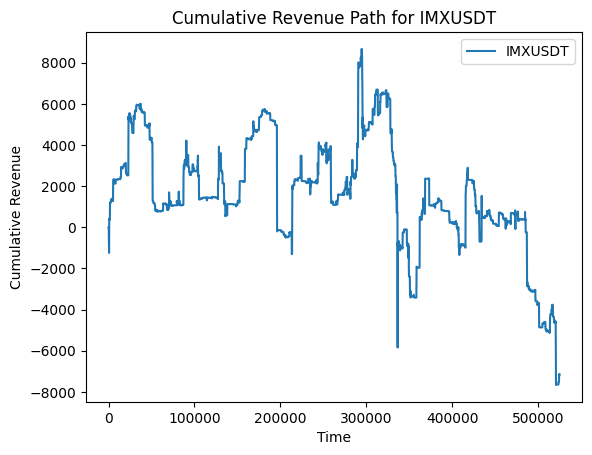

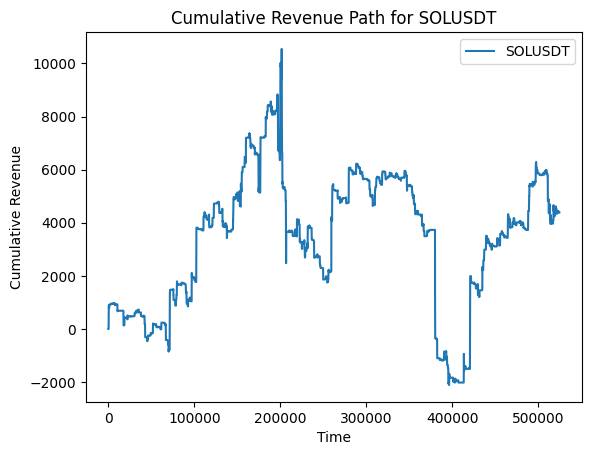

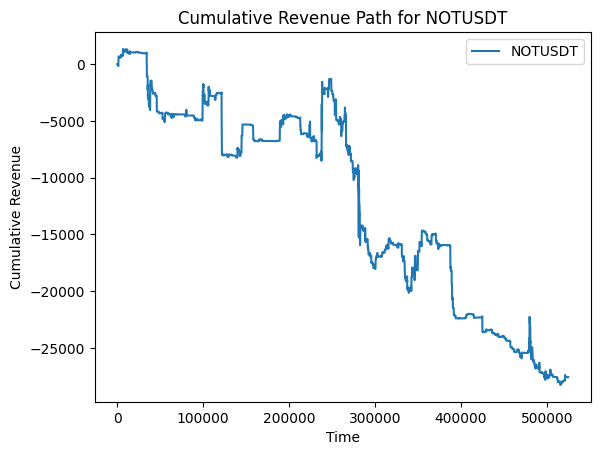

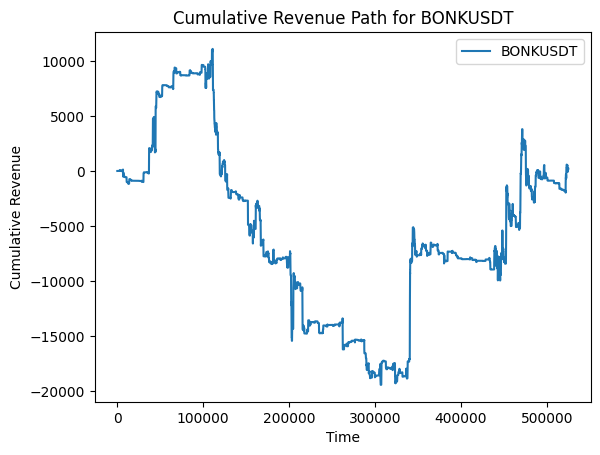

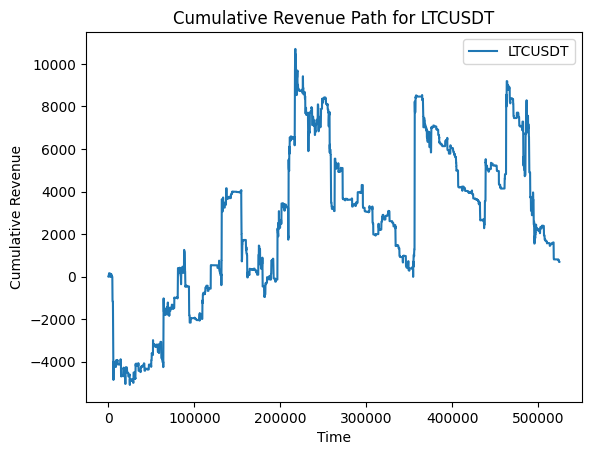

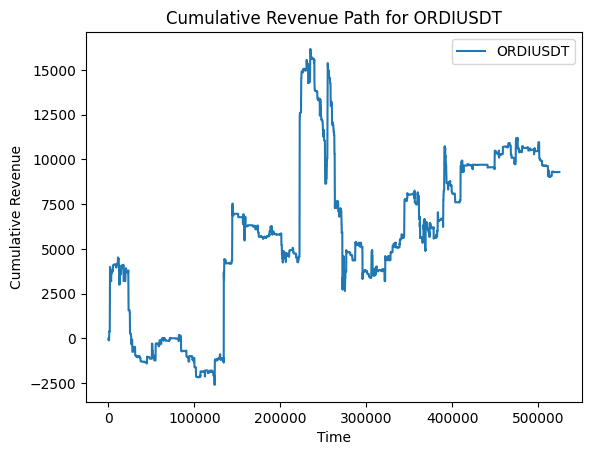

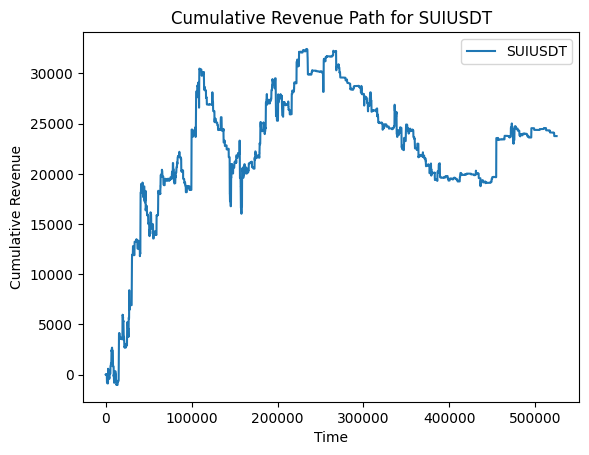

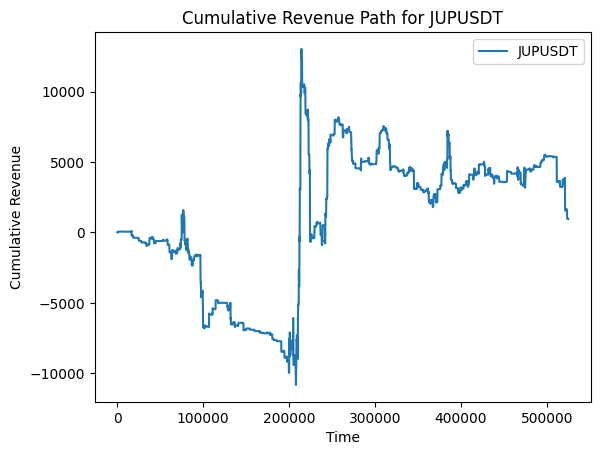

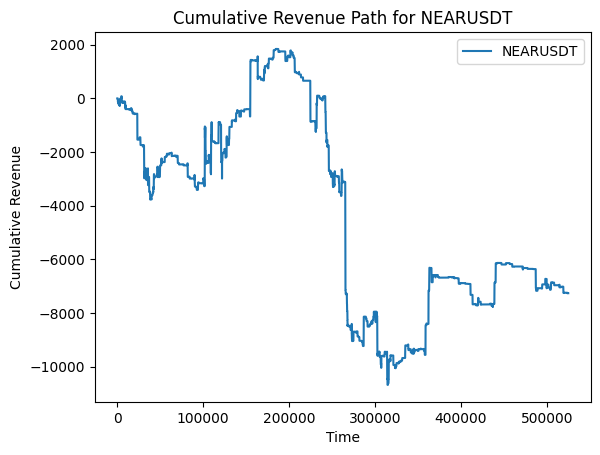

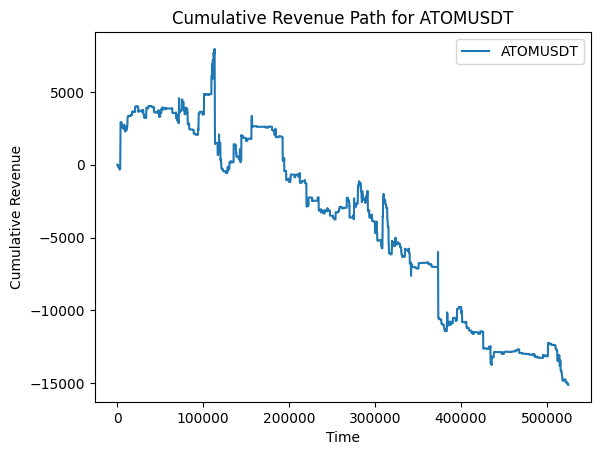

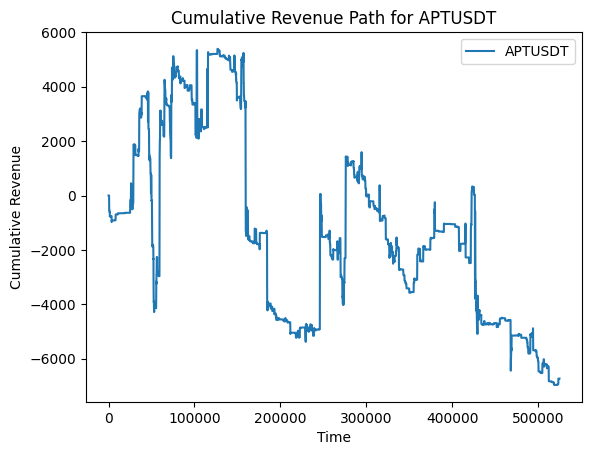

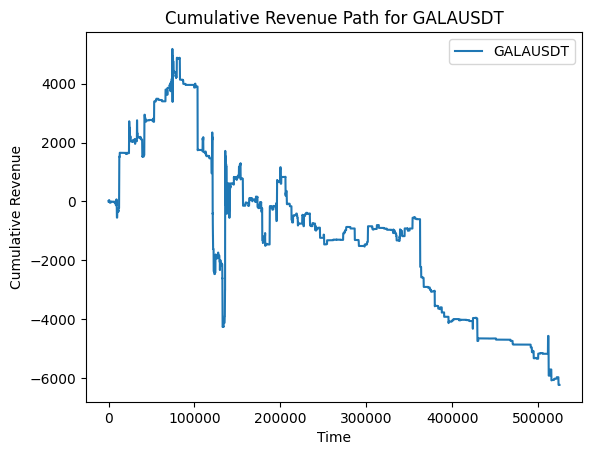

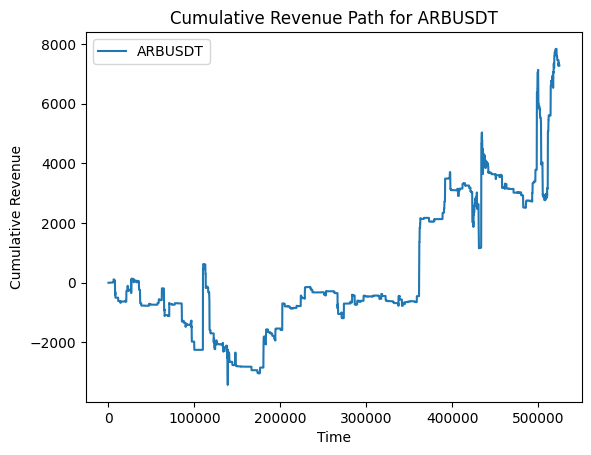

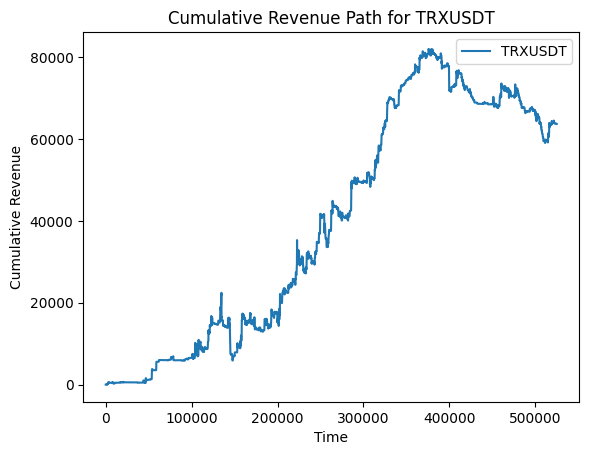

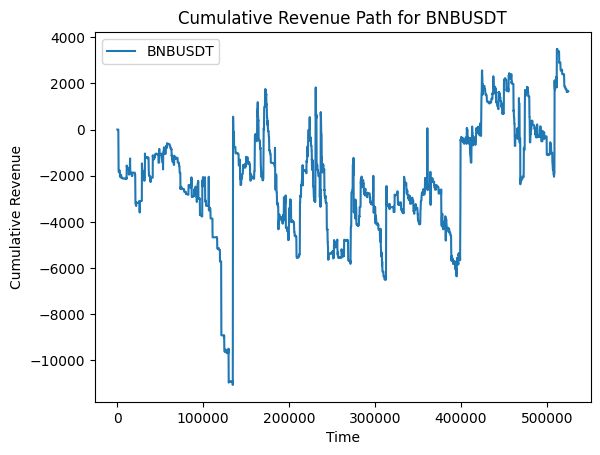

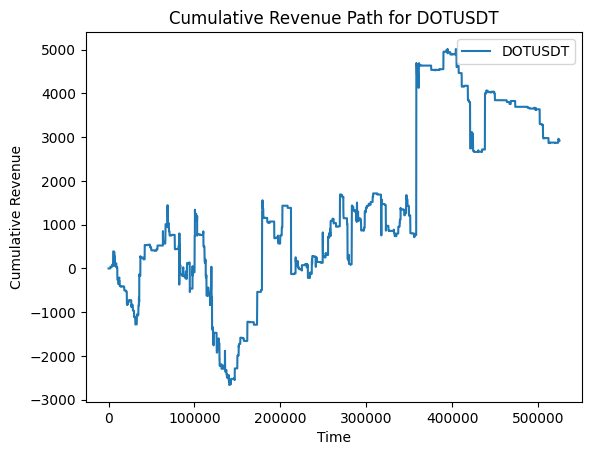

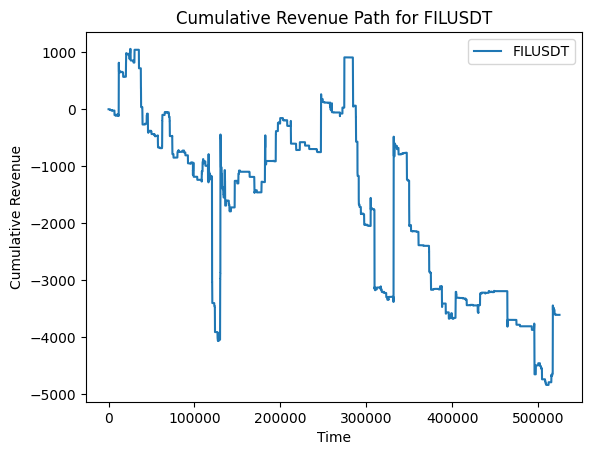

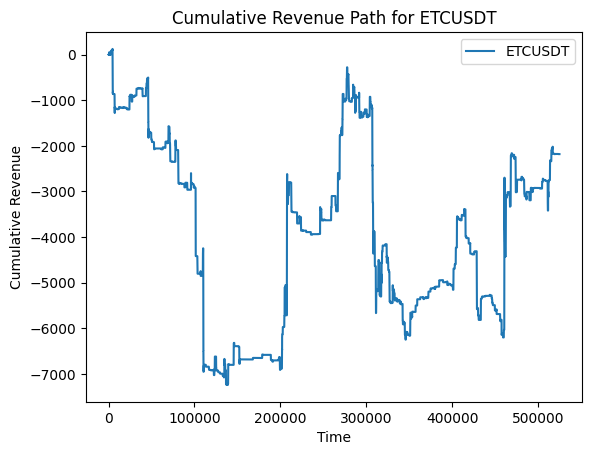

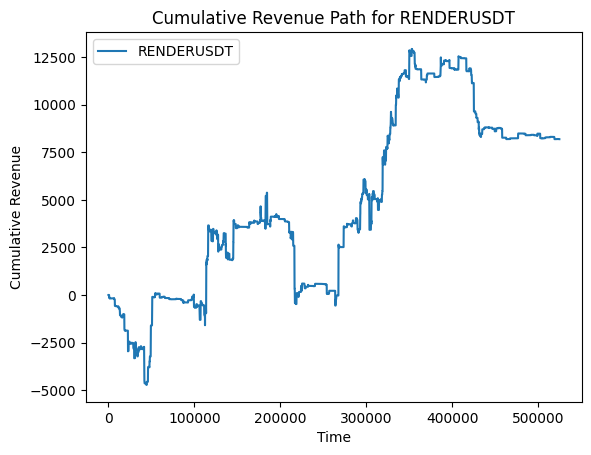

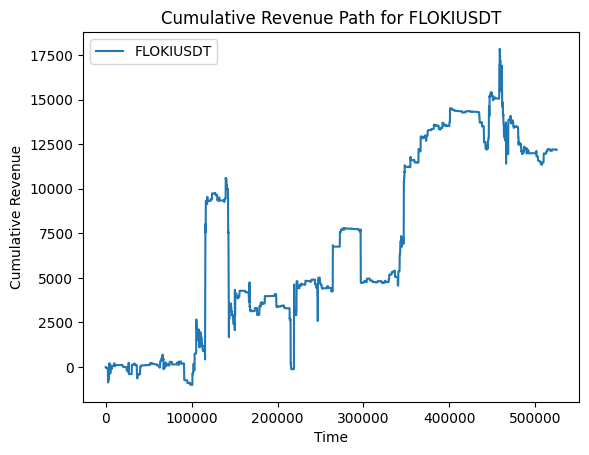

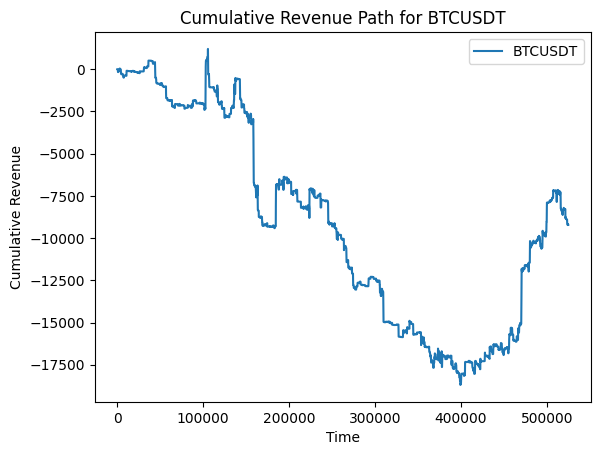

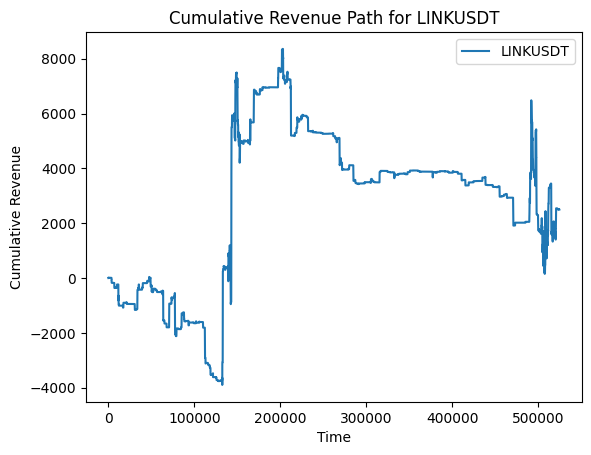

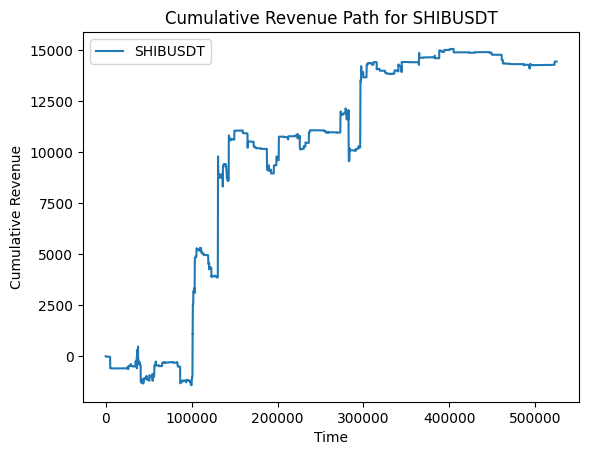

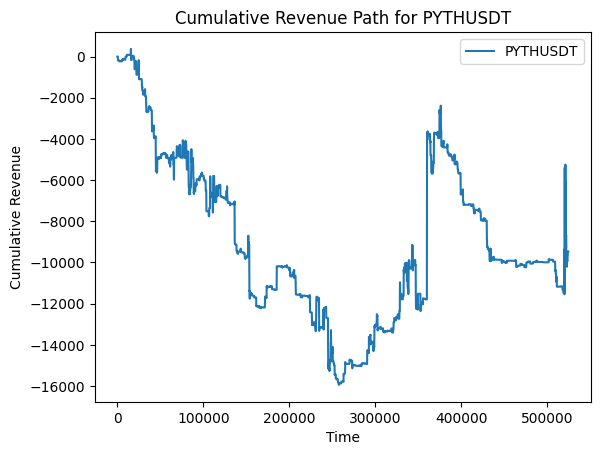

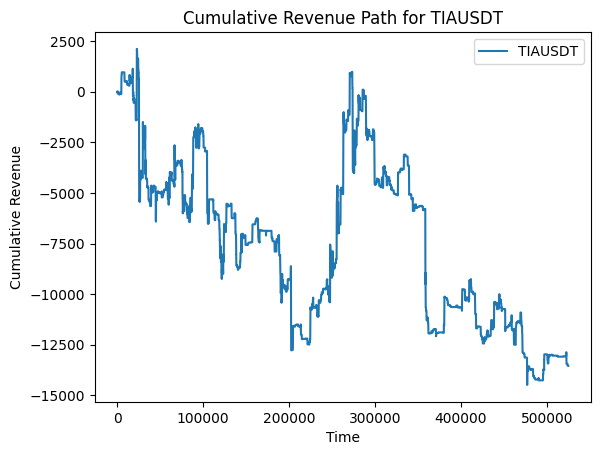

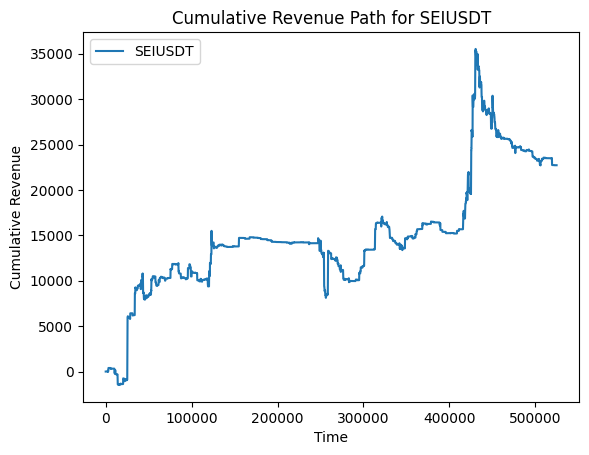

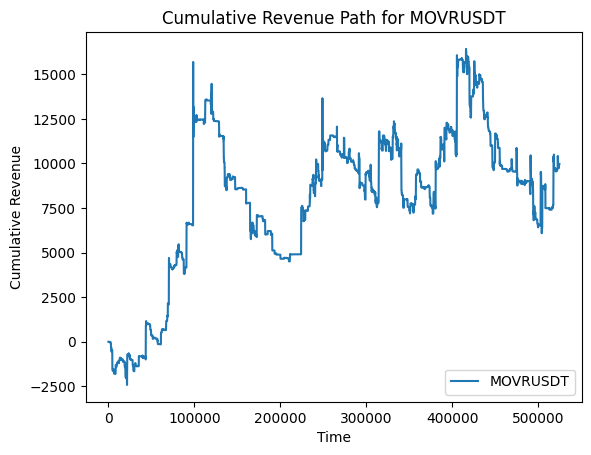

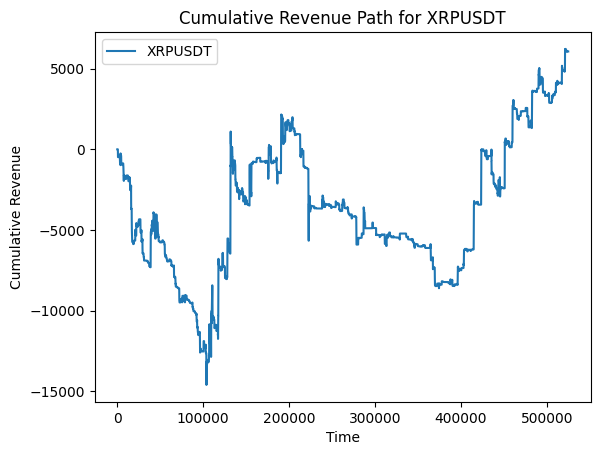

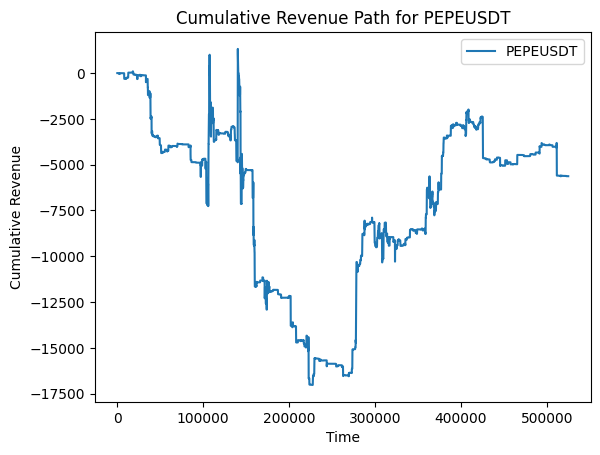

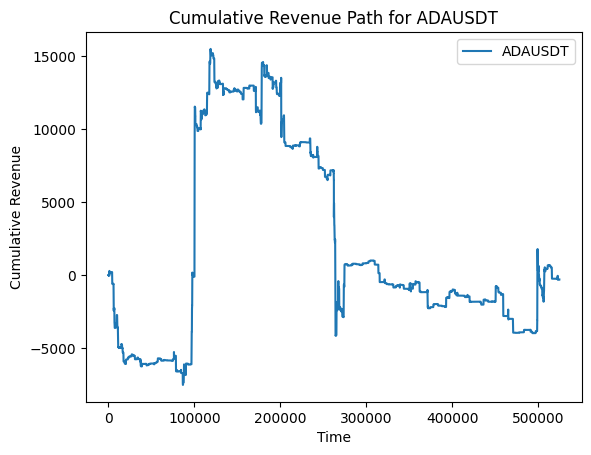

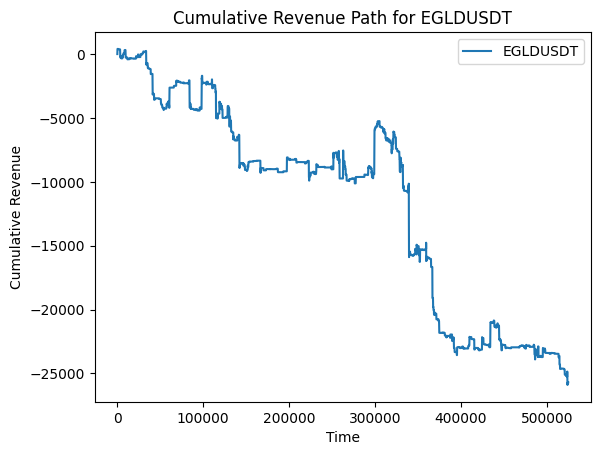

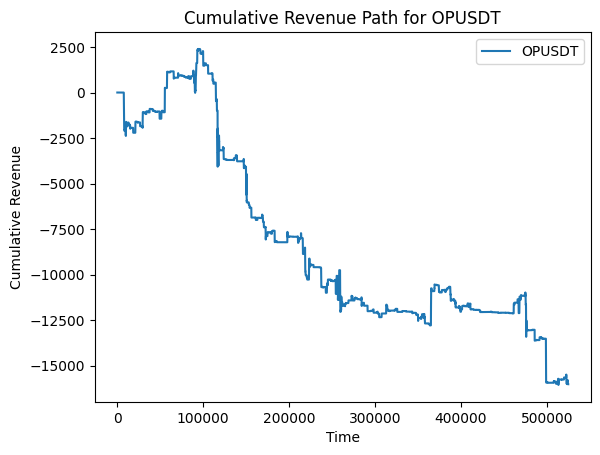

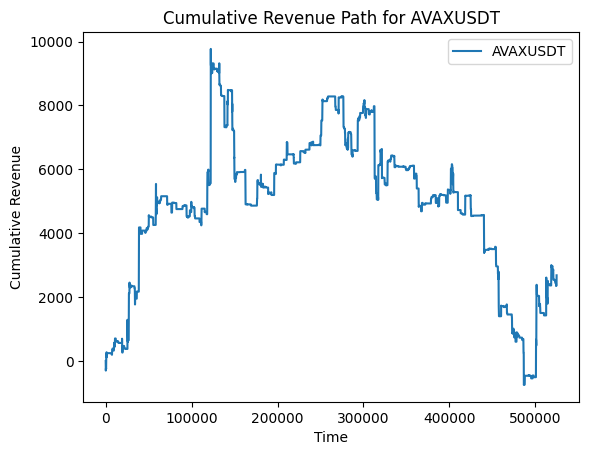

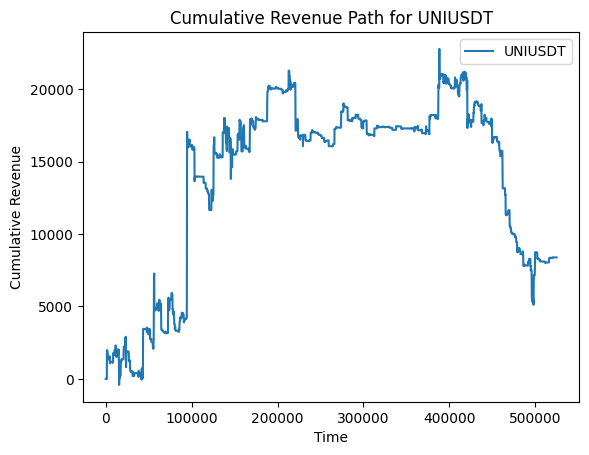

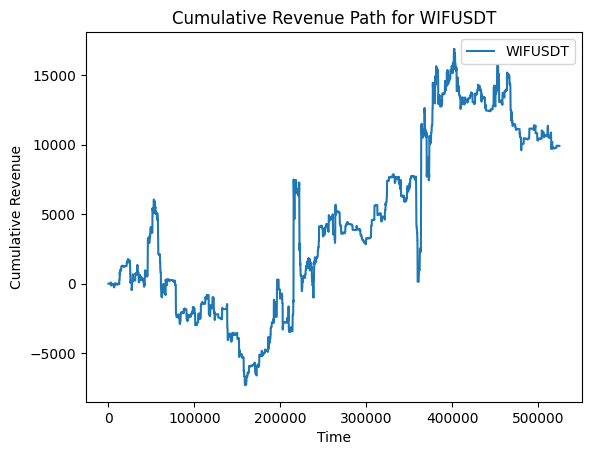

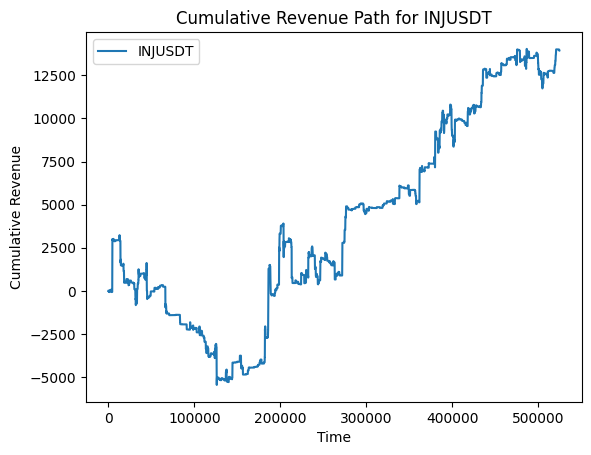

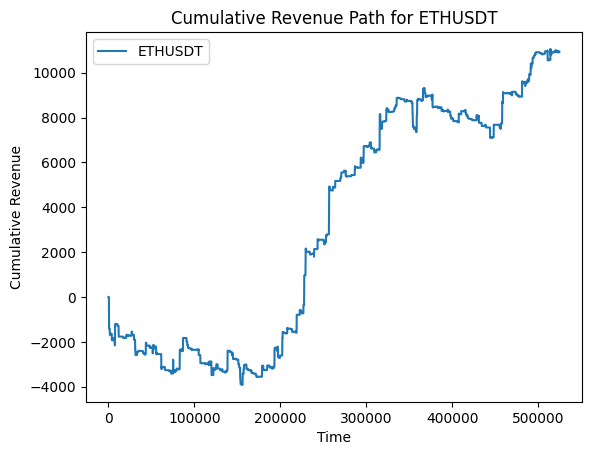

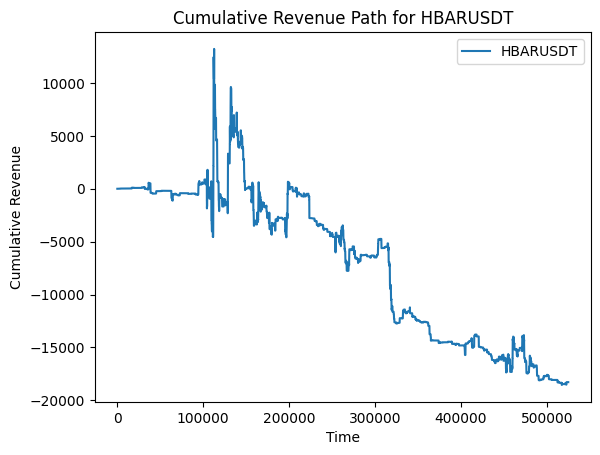

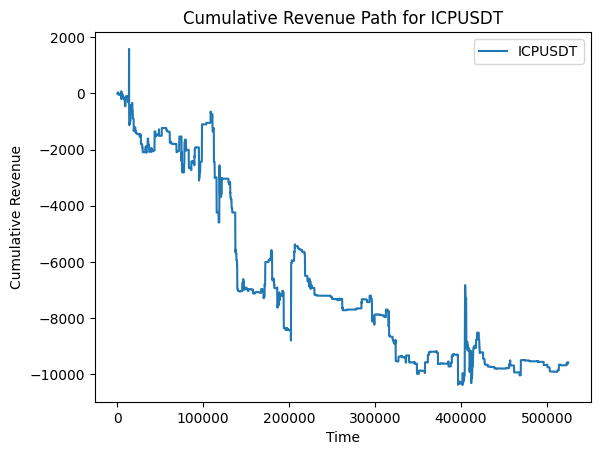

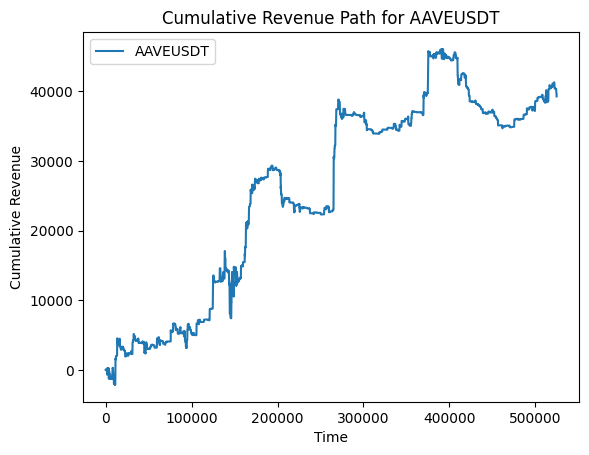

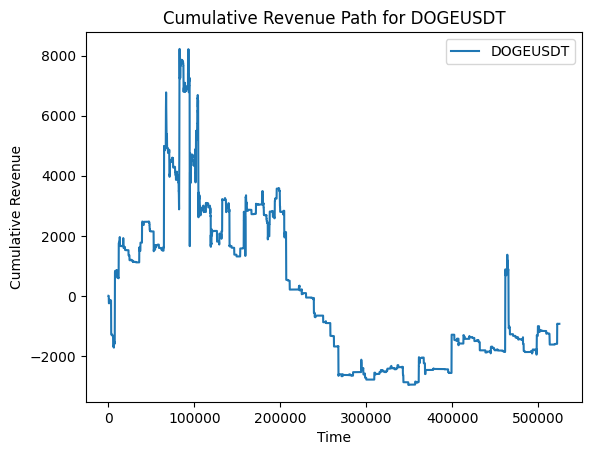

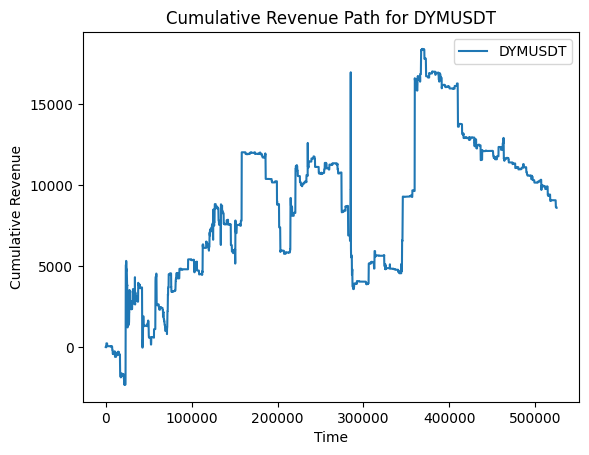

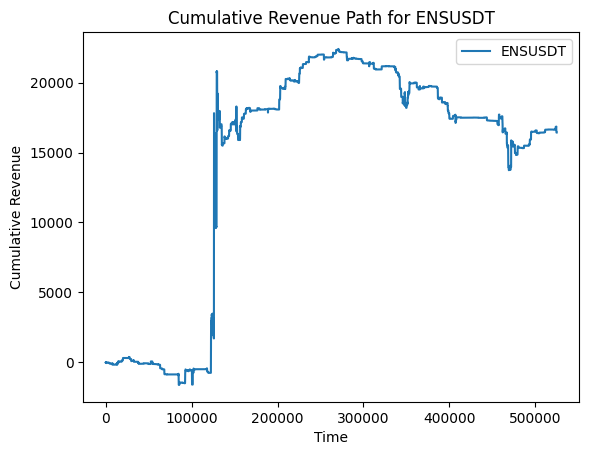

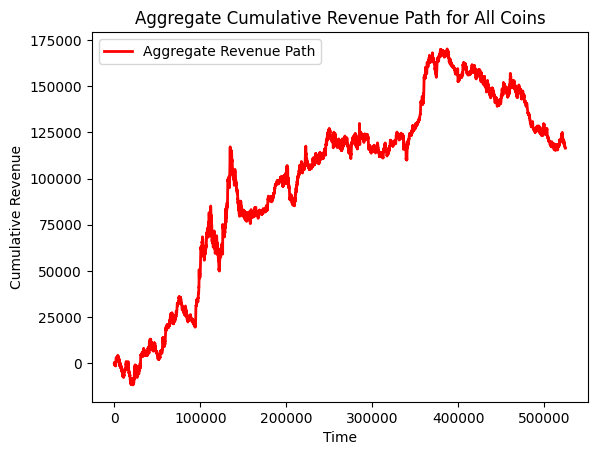

In [14]:
all_path = None

for coin in coins.columns:
    if coin == 'Unnamed: 0':
        continue
    coin_revs = np.array(coins[coin].dropna())
    coin_path = coin_revs.cumsum()
    if all_path is None:
        all_path = coin_path
    else:
        all_path = all_path + coin_path

    plt.plot(coin_path, label=coin)
    plt.title(f"Cumulative Revenue Path for {coin}")
    plt.xlabel("Time")
    plt.ylabel("Cumulative Revenue")
    plt.legend()
    plt.show()
    plt.close()
  
plt.plot(all_path, label="Aggregate Revenue Path", color='red', linewidth=2)
plt.title("Aggregate Cumulative Revenue Path for All Coins")
plt.xlabel("Time")
plt.ylabel("Cumulative Revenue")
plt.legend()
plt.show()
plt.close()

In [15]:
stats.columns

Index(['stats_1', 'stats_2', 'stats_3', 'stats_4', 'stats_5', 'stats_6',
       'stats_7', 'stats_8', 'stats_9', 'stats_10', 'revenues'],
      dtype='object')

=== Filtering Analysis ===
Total entries: 524800
Qualifying entries: 26095
Filtering rate: 4.97%
Original total revenue: 157258.391330
Filtered total revenue: 25075.182133
Revenue retention: 15.95%


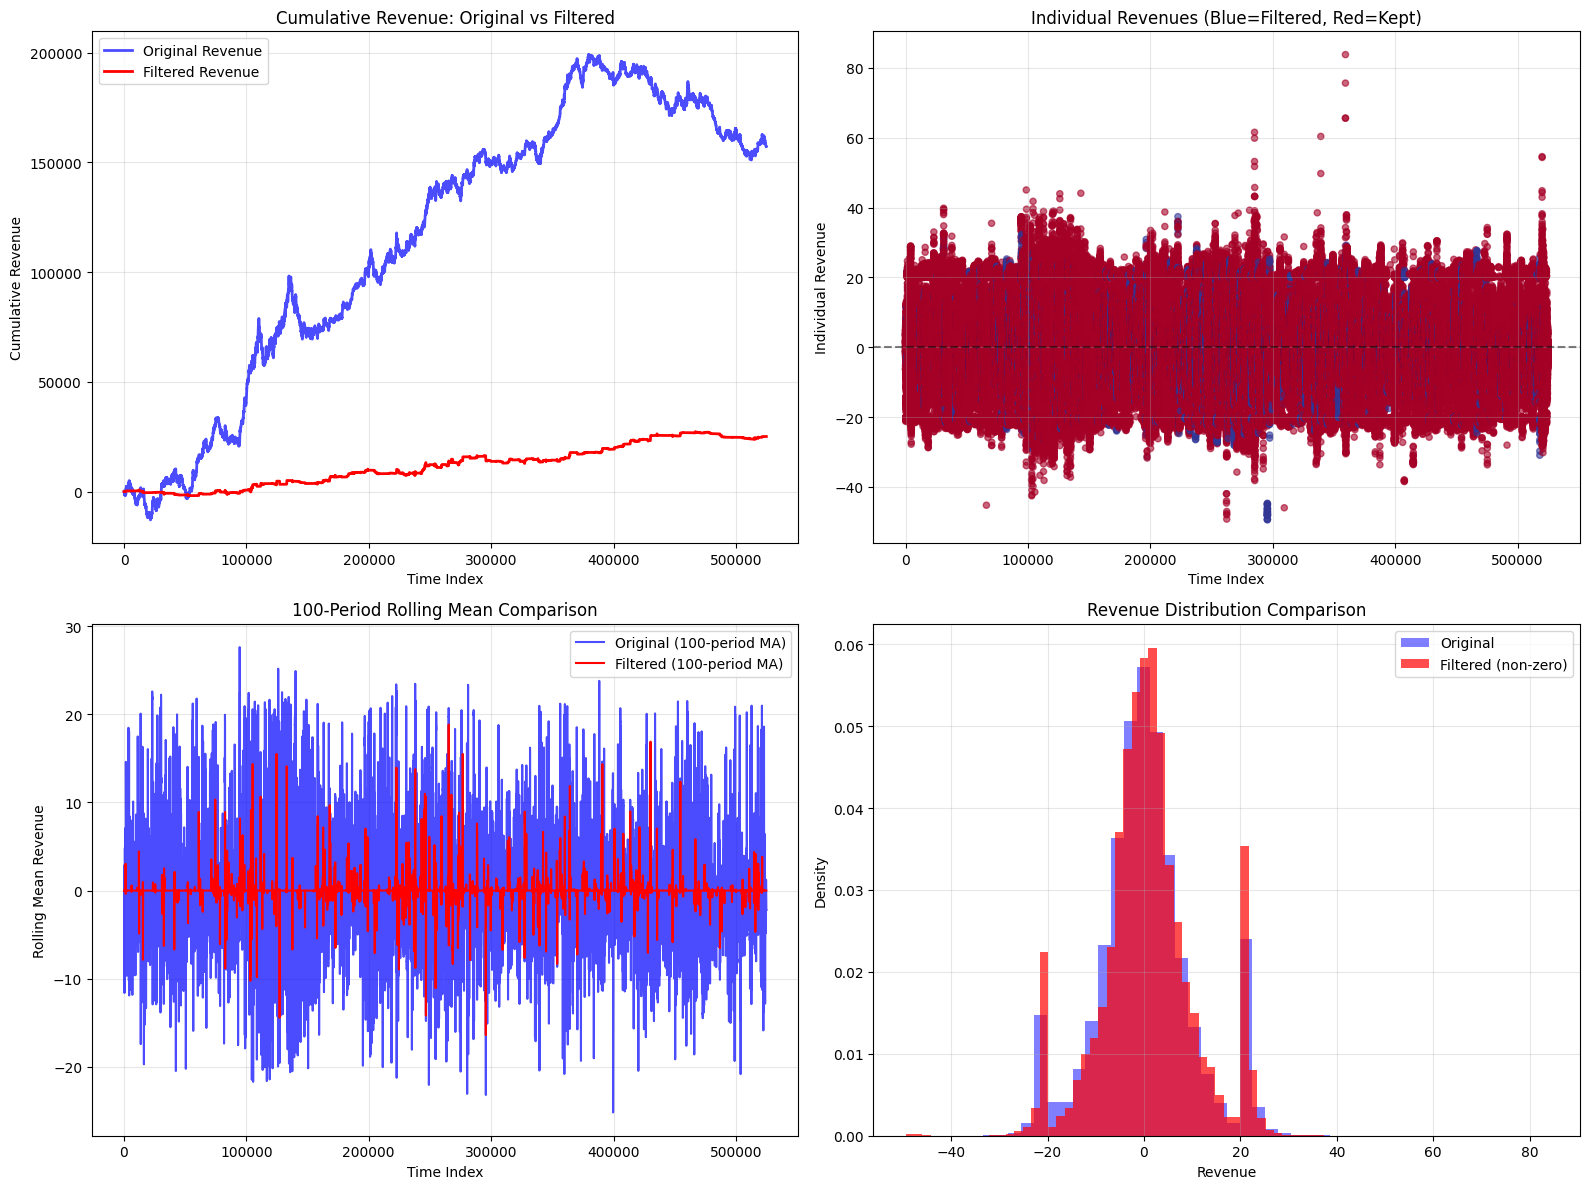


=== Performance Metrics ===
Original Revenue Stats:
  Mean: 0.299654
  Std:  9.908392
  Sharpe: 0.0302
  Win Rate: 49.45%

Filtered Revenue Stats (non-zero only):
  Mean: 0.960919
  Std:  9.896899
  Sharpe: 0.0971
  Win Rate: 53.35%

Filtered Revenue Stats (including zeros):
  Mean: 0.047780
  Std:  2.216714
  Sharpe: 0.0216
  Win Rate: 2.65%

=== Time-based Analysis ===
Chunk size: 100
Number of chunks: 5248
Original chunk mean: 29.965395
Filtered chunk mean: 4.778045


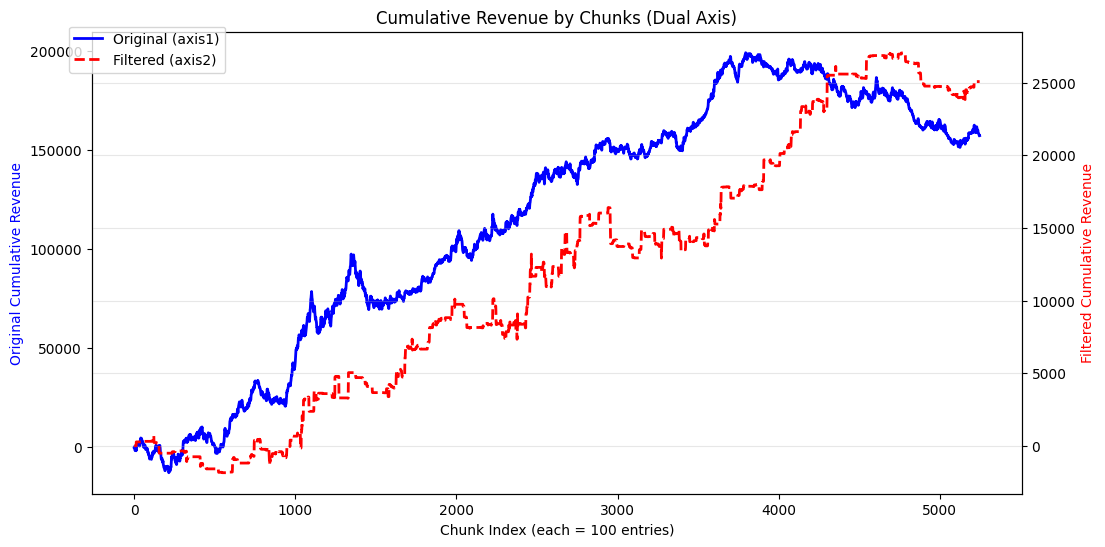


=== Filter Condition Analysis ===
Individual condition pass rates:
  stats_6 > 0.1:     10.59%
  stats_5 > 0.6:     59.85%
  stats_9 < 6:       89.14%
  stats_1 < -7500:   91.34%
  |stats_8| < 10:    84.53%
  All conditions:    4.97%


In [24]:
# if res.success and corr_2_mean>0.1 and corr_1_mean>0.6 and cmi_std<6 and objective_value < -7500  and abs(cmi_mean)<10:

# stats_1.append(objective_value)
# stats_2.append(coef_1_mean)
# stats_3.append(coef_2_mean)
# stats_4.append(coef_3_mean)
# stats_5.append(corr_1_mean)
# stats_6.append(corr_2_mean)
# stats_7.append(corr_3_mean)
# stats_8.append(cmi_mean)
# stats_9.append(cmi_std)
# stats_10.append(amihud_mean)

# Create filtered revenue series with 0s for non-qualifying entries
filtered_revenues = stats['revenues'].copy()

# Set revenues to 0 where conditions are not met
condition_mask = (
    (stats['stats_6'] > 0.1) &
    (stats['stats_5'] > 0.6) &
    (stats['stats_9'] < 6) &
    (stats['stats_1'] < -7500) &
    (stats['stats_8'].abs() < 10)
)

# Where condition is False, set revenue to 0
filtered_revenues[~condition_mask] = 0

# Calculate cumulative sum
cumulative_filtered = filtered_revenues.cumsum()
cumulative_original = stats['revenues'].cumsum()

# Print statistics
print("=== Filtering Analysis ===")
print(f"Total entries: {len(stats)}")
print(f"Qualifying entries: {condition_mask.sum()}")
print(f"Filtering rate: {condition_mask.sum() / len(stats):.2%}")
print(f"Original total revenue: {stats['revenues'].sum():.6f}")
print(f"Filtered total revenue: {filtered_revenues.sum():.6f}")
print(f"Revenue retention: {filtered_revenues.sum() / stats['revenues'].sum():.2%}")

# Create comprehensive plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Cumulative revenue comparison
axes[0, 0].plot(cumulative_original.index, cumulative_original.values, 
                label='Original Revenue', color='blue', alpha=0.7, linewidth=2)
axes[0, 0].plot(cumulative_filtered.index, cumulative_filtered.values, 
                label='Filtered Revenue', color='red', linewidth=2)
axes[0, 0].set_xlabel('Time Index')
axes[0, 0].set_ylabel('Cumulative Revenue')
axes[0, 0].set_title('Cumulative Revenue: Original vs Filtered')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Individual revenues with filtering
axes[0, 1].scatter(range(len(stats)), stats['revenues'], 
                   c=condition_mask, cmap='RdYlBu', alpha=0.6, s=20)
axes[0, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Time Index')
axes[0, 1].set_ylabel('Individual Revenue')
axes[0, 1].set_title('Individual Revenues (Blue=Filtered, Red=Kept)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Rolling statistics
window = 100
rolling_original = stats['revenues'].rolling(window).mean()
rolling_filtered = filtered_revenues.rolling(window).mean()

axes[1, 0].plot(rolling_original.index, rolling_original.values, 
                label=f'Original ({window}-period MA)', color='blue', alpha=0.7)
axes[1, 0].plot(rolling_filtered.index, rolling_filtered.values, 
                label=f'Filtered ({window}-period MA)', color='red')
axes[1, 0].set_xlabel('Time Index')
axes[1, 0].set_ylabel('Rolling Mean Revenue')
axes[1, 0].set_title(f'{window}-Period Rolling Mean Comparison')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Histogram comparison
axes[1, 1].hist(stats['revenues'], bins=50, alpha=0.5, label='Original', 
                color='blue', density=True)
axes[1, 1].hist(filtered_revenues[filtered_revenues != 0], bins=50, alpha=0.7, 
                label='Filtered (non-zero)', color='red', density=True)
axes[1, 1].set_xlabel('Revenue')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Revenue Distribution Comparison')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed performance analysis
print("\n=== Performance Metrics ===")
print(f"Original Revenue Stats:")
print(f"  Mean: {stats['revenues'].mean():.6f}")
print(f"  Std:  {stats['revenues'].std():.6f}")
print(f"  Sharpe: {stats['revenues'].mean() / stats['revenues'].std():.4f}")
print(f"  Win Rate: {(stats['revenues'] > 0).mean():.2%}")

print(f"\nFiltered Revenue Stats (non-zero only):")
non_zero_filtered = filtered_revenues[filtered_revenues != 0]
if len(non_zero_filtered) > 0:
    print(f"  Mean: {non_zero_filtered.mean():.6f}")
    print(f"  Std:  {non_zero_filtered.std():.6f}")
    print(f"  Sharpe: {non_zero_filtered.mean() / non_zero_filtered.std():.4f}")
    print(f"  Win Rate: {(non_zero_filtered > 0).mean():.2%}")
else:
    print("  No qualifying entries!")

print(f"\nFiltered Revenue Stats (including zeros):")
print(f"  Mean: {filtered_revenues.mean():.6f}")
print(f"  Std:  {filtered_revenues.std():.6f}")
print(f"  Sharpe: {filtered_revenues.mean() / filtered_revenues.std():.4f}")
print(f"  Win Rate: {(filtered_revenues > 0).mean():.2%}")

# Monthly/yearly analysis if applicable
print(f"\n=== Time-based Analysis ===")
chunk_size = 100  # Adjust based on your data frequency

chunks_original = [stats['revenues'].iloc[i:i+chunk_size].sum() 
                  for i in range(0, len(stats), chunk_size)]
chunks_filtered = [filtered_revenues.iloc[i:i+chunk_size].sum() 
                  for i in range(0, len(filtered_revenues), chunk_size)]

print(f"Chunk size: {chunk_size}")
print(f"Number of chunks: {len(chunks_original)}")
print(f"Original chunk mean: {np.mean(chunks_original):.6f}")
print(f"Filtered chunk mean: {np.mean(chunks_filtered):.6f}")

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
chunk_indices = range(len(chunks_original))
ax1.plot(chunk_indices, np.cumsum(chunks_original), 'b-', label='Original (axis1)', linewidth=2)
ax2.plot(chunk_indices, np.cumsum(chunks_filtered), 'r--', label='Filtered (axis2)', linewidth=2)
ax1.set_xlabel(f'Chunk Index (each = {chunk_size} entries)')
ax1.set_ylabel('Original Cumulative Revenue', color='b')
ax2.set_ylabel('Filtered Cumulative Revenue', color='r')
plt.title('Cumulative Revenue by Chunks (Dual Axis)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.grid(True, alpha=0.3)
plt.show()

# Filter condition analysis
print(f"\n=== Filter Condition Analysis ===")
print("Individual condition pass rates:")
print(f"  stats_6 > 0.1:     {(stats['stats_6'] > 0.1).mean():.2%}")
print(f"  stats_5 > 0.6:     {(stats['stats_5'] > 0.6).mean():.2%}")
print(f"  stats_9 < 6:       {(stats['stats_9'] < 6).mean():.2%}")
print(f"  stats_1 < -7500:   {(stats['stats_1'] < -7500).mean():.2%}")
print(f"  |stats_8| < 10:    {(stats['stats_8'].abs() < 10).mean():.2%}")
print(f"  All conditions:    {condition_mask.mean():.2%}")

# Save results
results_df = pd.DataFrame({
    'original_revenue': stats['revenues'],
    'filtered_revenue': filtered_revenues,
    'cumulative_original': cumulative_original,
    'cumulative_filtered': cumulative_filtered,
    'condition_met': condition_mask
})


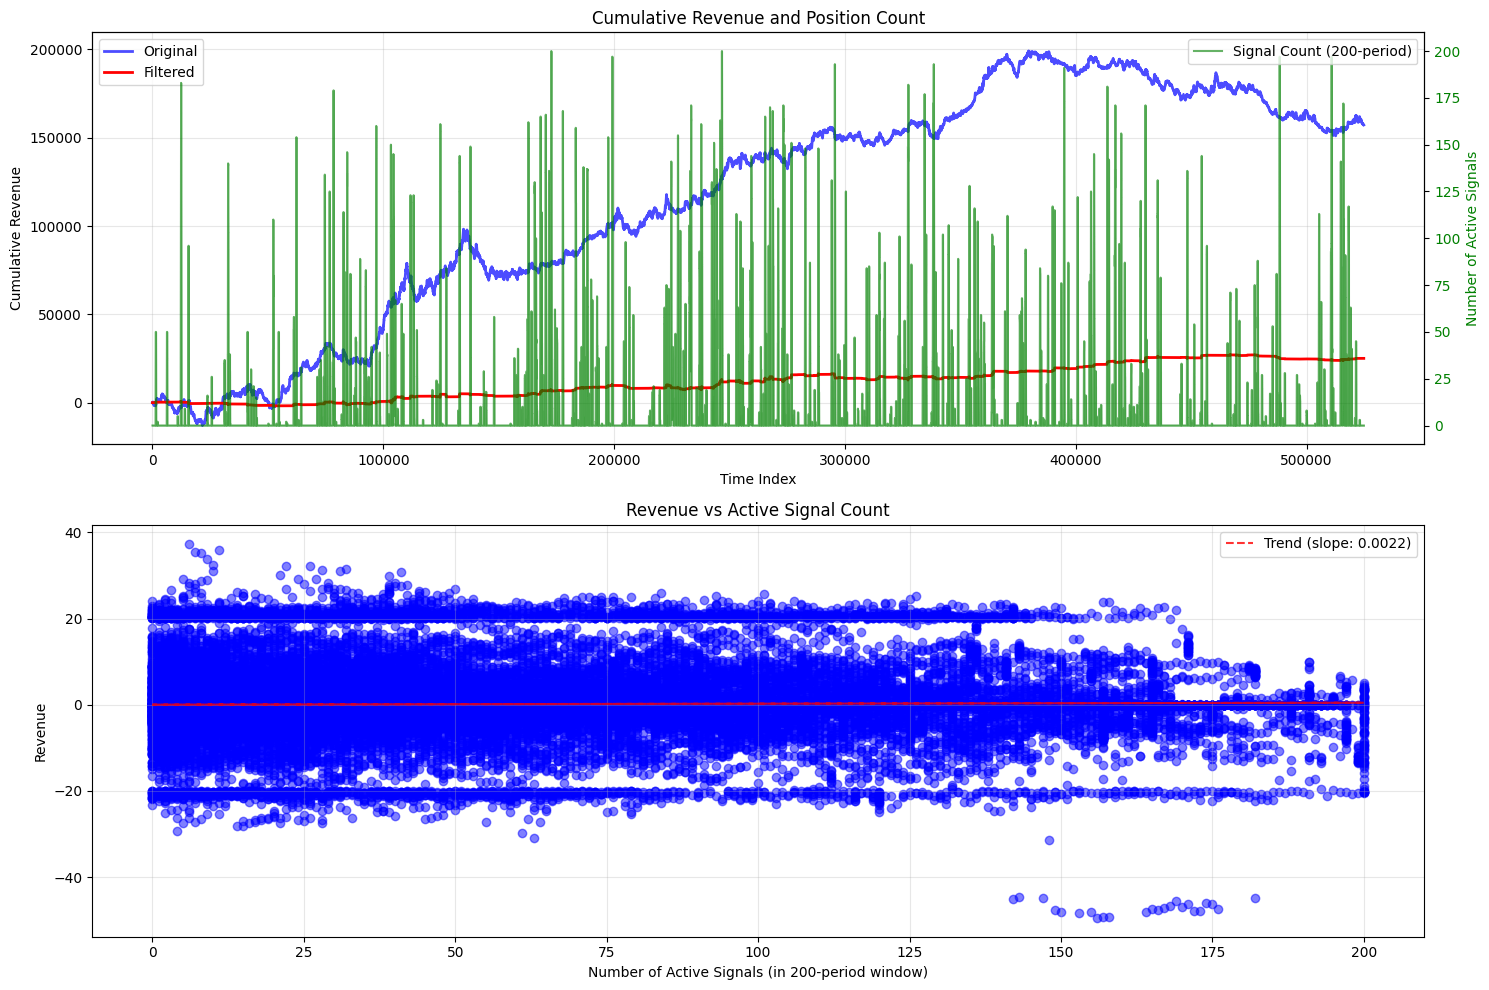


=== Signal Count Analysis (200-period window) ===
Average signals active: 9.94
Max signals active: 200
Min signals active: 0
Median signals active: 0.00
                signal_count_min  signal_count_max  signal_count_mean  \
bin                                                                     
(-0.001, 1.0]                0.0               1.0             0.4867   
(1.0, 2.0]                   2.0               2.0             2.0000   
(2.0, 3.0]                   3.0               3.0             3.0000   
(3.0, 4.0]                   4.0               4.0             4.0000   
(4.0, 6.0]                   5.0               6.0             5.4882   
(6.0, 8.0]                   7.0               8.0             7.4938   
(8.0, 10.0]                  9.0              10.0             9.5039   
(10.0, 13.0]                11.0              13.0            11.9868   
(13.0, 17.0]                14.0              17.0            15.4918   
(17.0, 21.0]                18.0           

/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_16183/4077440391.py:69: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_by_bin = revenue_nonzero.groupby('bin').agg({


In [33]:
# Modified signal count analysis
window = 200
signal_counts = pd.Series(np.zeros(len(stats)), index=stats.index)
for i in range(len(stats)):
    if i >= window:
        signal_counts[i] = condition_mask[i-window:i].sum()
    else:
        signal_counts[i] = condition_mask[:i].sum()

# Create plot with dual y-axes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Cumulative Revenue with Signal Count
ax1.plot(cumulative_original.index, cumulative_original.values, 
         label='Original', color='blue', alpha=0.7, linewidth=2)
ax1.plot(cumulative_filtered.index, cumulative_filtered.values, 
         label='Filtered', color='red', linewidth=2)
ax1.set_xlabel('Time Index')
ax1.set_ylabel('Cumulative Revenue')
ax1.set_title('Cumulative Revenue and Position Count')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Add position count on secondary y-axis
ax12 = ax1.twinx()
ax12.fill_between(signal_counts.index, signal_counts.values, alpha=0.2, color='green')
ax12.plot(signal_counts.index, signal_counts.values, color='green', alpha=0.6, 
          label=f'Signal Count ({window}-period)')
ax12.set_ylabel('Number of Active Signals', color='green')
ax12.tick_params(axis='y', labelcolor='green')
ax12.legend(loc='upper right')

# Plot 2: Signal Count vs Revenue with Enhanced Analysis
ax2.scatter(signal_counts, filtered_revenues, alpha=0.5, c='blue')
ax2.set_xlabel(f'Number of Active Signals (in {window}-period window)')
ax2.set_ylabel('Revenue')
ax2.set_title('Revenue vs Active Signal Count')
ax2.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(signal_counts, filtered_revenues, 1)
p = np.poly1d(z)
ax2.plot(signal_counts, p(signal_counts), "r--", alpha=0.8, 
         label=f'Trend (slope: {z[0]:.4f})')
ax2.legend()

plt.tight_layout()
plt.show()

# Print basic statistics
print(f"\n=== Signal Count Analysis ({window}-period window) ===")
print(f"Average signals active: {signal_counts.mean():.2f}")
print(f"Max signals active: {signal_counts.max():.0f}")
print(f"Min signals active: {signal_counts.min():.0f}")
print(f"Median signals active: {signal_counts.median():.2f}")

# Modified quantile analysis to handle duplicates
# Create custom bins based on signal distribution
signal_bins = pd.qcut(signal_counts, q=80, duplicates='drop')
revenue_by_signals = pd.DataFrame({
    'signal_count': signal_counts,
    'revenue': filtered_revenues,
    'bin': signal_bins
})
# 只保留 revenue ≠ 0 的记录
revenue_nonzero = revenue_by_signals[revenue_by_signals['revenue'] != 0]

# 按 bin 分组统计
stats_by_bin = revenue_nonzero.groupby('bin').agg({
    'signal_count': ['min', 'max', 'mean', 'count'],
    'revenue': [
        'mean', 
        'std', 
        ('pos_ratio', lambda x: (x > 0).mean())  # 自定义命名: 正收益比例
    ]
}).round(4)

# 整理列名
stats_by_bin.columns = ['_'.join(col).strip() for col in stats_by_bin.columns.values]

print(stats_by_bin)

# Additional analysis of extreme cases
high_signal_periods = revenue_by_signals[revenue_by_signals['signal_count'] > signal_counts.quantile(0.9)]
print("\nHigh Signal Periods Analysis (top 10%):")
print(f"Number of periods: {len(high_signal_periods)}")
print(f"Average revenue: {high_signal_periods['revenue'].mean():.4f}")
print(f"Win rate: {(high_signal_periods['revenue'] > 0).mean():.2%}")

In [16]:
# random_seed = 42
# np.random.seed(random_seed)
# train_frac = 0.6
# size = len(stats)
# train_size = int(size * train_frac)
# shuffled_indices = np.random.permutation(size)
# train_indices = shuffled_indices[:train_size]
# test_indices = shuffled_indices[train_size:]
# train_set = stats.iloc[train_indices]
# test_set = stats.iloc[test_indices]

train_set = stats[:int(0.6*len(stats))]
test_set = stats[int(0.6*len(stats)):]

In [17]:
train_means = train_set.mean()
test_means = test_set.mean()


In [18]:
train_means

stats_1     -12012.078113
stats_2         24.529512
stats_3         -0.077841
stats_4     863155.538937
stats_5          0.621967
stats_6          0.017798
stats_7          0.674536
stats_8         -0.039991
stats_9          4.588901
stats_10     21308.989225
revenues         0.481901
dtype: float64

In [19]:
test_means

stats_1     -12061.460391
stats_2         24.569565
stats_3          0.248645
stats_4     955582.605722
stats_5          0.614355
stats_6          0.020968
stats_7          0.692937
stats_8          0.272175
stats_9          4.385176
stats_10     31396.189369
revenues         0.026283
dtype: float64

In [20]:
train_set.columns

Index(['stats_1', 'stats_2', 'stats_3', 'stats_4', 'stats_5', 'stats_6',
       'stats_7', 'stats_8', 'stats_9', 'stats_10', 'revenues'],
      dtype='object')

In [21]:
# 修正后的代码
X_train = train_set[['stats_1', 'stats_2', 'stats_3', 'stats_4', 'stats_5', 
                     'stats_6', 'stats_7', 'stats_8', 'stats_9', 'stats_10']]
y_train = train_set['revenues']

X_test = test_set[['stats_1', 'stats_2', 'stats_3', 'stats_4', 'stats_5', 
                   'stats_6', 'stats_7', 'stats_8', 'stats_9', 'stats_10']]
y_test = test_set['revenues']

# 检查数据形状
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# 或者更简洁的写法
feature_columns = [f'stats_{i}' for i in range(1, 11)]
X_train = train_set[feature_columns]
y_train = train_set['revenues']
X_test = test_set[feature_columns]
y_test = test_set['revenues']

# 检查数据预览
print("\nX_train preview:")
print(X_train.head())
print("\ny_train preview:")
print(y_train.head())

X_train shape: (314880, 10)
y_train shape: (314880,)
X_test shape: (209920, 10)
y_test shape: (209920,)

X_train preview:
       stats_1    stats_2   stats_3        stats_4   stats_5   stats_6  \
0 -9103.298684  24.539243  0.633408  430017.135387  0.612799  0.025058   
1 -8114.276563  24.537178  0.587404  428317.903382  0.611208  0.024158   
2 -8246.404336  24.536466  0.619629  428318.162395  0.611532  0.023356   
3 -7725.995924  24.546215  0.693723  427250.801294  0.613767  0.025033   
4 -8357.125236  24.546706  0.616793  427305.761388  0.613725  0.021010   

    stats_7   stats_8   stats_9      stats_10  
0  0.517402 -0.766518  4.286362  18969.347096  
1  0.516903 -1.462128  4.378475  18969.347118  
2  0.517040 -1.847377  4.295066  18969.347118  
3  0.516907 -1.323261  4.158676  18969.347111  
4  0.516858 -1.880591  4.281604  21847.970015  

y_train preview:
0    3.382310
1    4.224834
2    3.038458
3    3.421236
4   -1.249761
Name: revenues, dtype: float64
